<a href="https://colab.research.google.com/github/vi-xoxo/BigData26_KelasB_2311533010_Irgi-Fatihul-Ihsan/blob/main/Praktikum2/BD_KELAS_B_PO2_2311533010_IRGI_FATIHUL_IHSAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Persiapan: Instalasi Faker


In [1]:
!pip install faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.5 MB/s eta 0:00:00


`-q` membuat instalasi berjalan senyap. Jika tidak ada error, Faker siap dipakai.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")   # ikuti dialog izin yang muncul

import os
DIR_KERJA  = "/content/data"                              # sementara, cepat
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum2"   # permanen
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

## K-1. Import Library dan Inisialisasi
menyiapkan seluruh pustaka yang dipakai sepanjang praktikum.

In [2]:
import numpy as np
import pandas as pd
from faker import Faker
import random

print("Versi pandas:", pd.__version__)

Versi pandas: 2.2.3


**Interpretasi:**
- `numpy` → angka acak, `pandas` → data tabular, `Faker` → data palsu (nama, kota, kata), `random` → pemilihan acak.
- Versi pandas dicetak untuk berjaga-jaga jika ada sel yang gagal (modul menyarankan pandas ≥ 2.0).

## K-2. Membuat Dataset Sintetis (Simulasi Data Acquisition)
Kode berikut mensimulasikan *acquisition* data transaksi. Sengaja disisipkan variasi format harga, format tanggal, kapitalisasi, *missing value*, dan baris *duplicate* agar mirip data mentah dunia nyata.

In [3]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
fake = Faker("id_ID")
Faker.seed(SEED)

N = 500
kategori_produk = ["Elektronik", "Fashion", "Kesehatan", "Rumah Tangga", "Olahraga", "Buku"]
metode_bayar = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]

rows = []
for i in range(1, N + 1):
    trx_id = f"TRX{i:05d}"
    nama_pelanggan = fake.name()
    produk = fake.word().capitalize() + " " + random.choice(["Pro", "Lite", "Max", "Basic", ""])
    kategori = random.choice(kategori_produk)
    harga_dasar = random.choice([15000, 25000, 50000, 75000, 120000, 250000, 500000, 1200000])
    qty = random.randint(1, 5)

    # Variasi format harga: angka polos, ada "Rp", ada desimal ".0", ada spasi
    harga_variants = [
        str(harga_dasar),
        f"Rp{harga_dasar:,}".replace(",", "."),
        f"{harga_dasar}.0",
        f" {harga_dasar} ",
    ]
    harga = random.choice(harga_variants)

    # Variasi format tanggal: ISO, DD/MM/YYYY, DD-MM-YYYY
    tgl = fake.date_between(start_date="-90d", end_date="today")
    tgl_variants = [tgl.strftime("%Y-%m-%d"), tgl.strftime("%d/%m/%Y"), tgl.strftime("%d-%m-%Y")]
    tanggal = random.choice(tgl_variants)

    metode = random.choice(metode_bayar)
    if random.random() < 0.3:
        metode = metode.lower()
    if random.random() < 0.2:
        kategori = kategori.upper() + " "

    kota = fake.city()
    rating = random.choice([1, 2, 3, 4, 5, None, None])  # rating opsional

    rows.append({
        "transaction_id": trx_id, "customer_name": nama_pelanggan, "product_name": produk.strip(),
        "category": kategori, "price": harga, "quantity": qty, "payment_method": metode,
        "transaction_date": tanggal, "shipping_city": kota, "rating": rating,
    })

df = pd.DataFrame(rows)

# Suntikkan missing value pada beberapa kolom
for col, frac in [("customer_name", 0.02), ("shipping_city", 0.03), ("payment_method", 0.015)]:
    idx = df.sample(frac=frac, random_state=SEED).index
    df.loc[idx, col] = np.nan

# Duplikasi 15 baris (mensimulasikan transaksi yang tercatat dua kali)
dup_rows = df.sample(n=15, random_state=SEED)
df = pd.concat([df, dup_rows], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df.to_csv("transaksi_mentah.csv", index=False)
print("Jumlah baris:", len(df))

Jumlah baris: 515


- Output harus **515 baris** = 500 transaksi asli + 15 duplikat. Angka ini pasti karena `SEED = 42`.
- File `transaksi_mentah.csv` tersimpan sebagai data mentah (raw data).
- `Faker.seed()` dan `np.random.seed()` dipanggil keduanya karena mengendalikan dua generator acak yang berbeda, agar hasil reproducible.

Lihat sekilas data mentah untuk melihat masalah formatnya:

In [4]:
df.head(8)

,transaction_id,customer_name,product_name,category,price,quantity,payment_method,transaction_date,shipping_city,rating
0,TRX00305,Ophelia Hartati,Quo Basic,Buku,50000,4,kartu kredit,2026-07-21,Blitar,1.0
1,TRX00500,Cut Maya Wijayanti,Delectus,Elektronik,Rp500.000,1,E-Wallet,2026-07-17,Lubuklinggau,NaN
2,TRX00442,"Dr. Ridwan Utama, M.Pd",Animi Max,Elektronik,25000,1,COD,2026-09-02,Probolinggo,2.0
3,TRX00154,"Viman Suwarno, S.H.",Consectetur,Fashion,Rp250.000,1,COD,04/08/2026,Tual,4.0
4,TRX00074,NaN,Eius,Olahraga,250000.0,4,NaN,09/07/2026,NaN,1.0
5,TRX00132,Ir. Ilyas Setiawan,Ducimus Pro,Rumah Tangga,250000,4,COD,23/09/2026,Subulussalam,2.0
6,TRX00205,Agnes Najmudin,Dicta Pro,Rumah Tangga,120000,1,E-Wallet,15/08/2026,Batam,2.0
7,TRX00010,"dr. Elisa Uwais, S.I.Kom",Eos Max,Fashion,1200000,4,cod,2026-08-25,NaN,5.0


kolom `price` bercampur teks (`Rp...`, `.0`, spasi), `transaction_date` punya beberapa format, dan `category`/`payment_method` kapitalisasinya tidak seragam. Semua ini yang akan dibereskan.

## K-3. Deteksi dan Penanganan Missing Value
Langkah pertama: hitung *missing value* per kolom.

In [5]:
print(df.isnull().sum())

transaction_id        0
customer_name        20
product_name          0
category              0
price                 0
quantity              0
payment_method       16
transaction_date      0
shipping_city        30
rating              166
dtype: int64


kolom yang kosong: `customer_name` = 20, `payment_method` = 16, `shipping_city` = 30, `rating` = 166. Kolom lain tidak ada yang kosong. (Angka sudah termasuk baris duplikat.)

**Strategi penanganan (ditentukan per kolom, tidak disamaratakan):**

| Kolom | Strategi | Alasan |
|---|---|---|
| `customer_name` | Buang baris (`dropna`) | Nama pembeli wajib untuk identifikasi transaksi |
| `payment_method` | Buang baris (`dropna`) | Metode pembayaran adalah informasi inti transaksi |
| `shipping_city` | Isi `"Tidak Diketahui"` (`fillna`) | Baris tetap berguna untuk analisis lain |
| `rating` | Biarkan kosong (NaN) | Rating memang opsional |

In [6]:
df = df.dropna(subset=["customer_name", "payment_method"])
df["shipping_city"] = df["shipping_city"].fillna("Tidak Diketahui")

print("Jumlah baris setelah dropna:", len(df))
print()
print(df.isnull().sum())

Jumlah baris setelah dropna: 495

transaction_id        0
customer_name         0
product_name          0
category              0
price                 0
quantity              0
payment_method        0
transaction_date      0
shipping_city         0
rating              158
dtype: int64


- Baris turun dari 515 menjadi **495** (20 baris dibuang karena `customer_name`/`payment_method` kosong).
- Setelah penanganan, **hanya `rating` yang masih boleh kosong**, sesuai target modul.

## K-4. Deteksi dan Penanganan Duplicate

In [7]:
print("Baris duplicate (semua kolom sama):", df.duplicated().sum())
print("transaction_id duplicate:", df['transaction_id'].duplicated().sum())

df = df.drop_duplicates()
print("Jumlah baris setelah drop_duplicates():", len(df))

Baris duplicate (semua kolom sama): 5
transaction_id duplicate: 5
Jumlah baris setelah drop_duplicates(): 490


- Pada langkah ini terdeteksi **5 duplicate** dan jumlah baris menjadi **490**.
- Angka 5 (bukan 15) karena `dropna` di K-3 sudah membuang 10 dari 15 baris duplicate (baris tersebut kebetulan membawa nilai kosong). Hasil akhir tetap 490.
- `duplicated()` semua kolom = `transaction_id` duplicate, artinya duplikat ini murni salinan persis.

Pembuktian: berapa duplicate pada **data mentah** sebelum apa pun dibuang (sesuai contoh output modul)?

In [8]:
mentah = pd.read_csv("transaksi_mentah.csv")
print("Baris duplicate (semua kolom sama):", mentah.duplicated().sum())
print("transaction_id duplicate:", mentah['transaction_id'].duplicated().sum())
print("Jumlah baris setelah drop_duplicates():", len(mentah.drop_duplicates()))

Baris duplicate (semua kolom sama): 15
transaction_id duplicate: 15
Jumlah baris setelah drop_duplicates(): 500


pada data mentah ada **15 duplicate**, dan setelah dihapus tersisa **500 baris**. Ini sesuai contoh modul, dan menunjukkan mengapa `drop_duplicates()` sebaiknya dijalankan lebih awal (lihat M.3 pada modul).

## K-5. Koreksi Tipe Data dan Standardisasi Format
### a. Standardisasi teks kategorikal (`category`, `payment_method`, `shipping_city`)

In [9]:
for col in ["category", "payment_method", "shipping_city"]:
    df[col] = df[col].astype("string").str.strip().str.title()

# "Cod" adalah singkatan; kembalikan ke huruf kapital penuh setelah Title Case
df["payment_method"] = df["payment_method"].replace({"Cod": "COD"})

print("category      :", df["category"].nunique(), "nilai unik ->", sorted(df["category"].unique()))
print("payment_method:", df["payment_method"].nunique(), "nilai unik ->", sorted(df["payment_method"].unique()))

category      : 6 nilai unik -> ['Buku', 'Elektronik', 'Fashion', 'Kesehatan', 'Olahraga', 'Rumah Tangga']
payment_method: 4 nilai unik -> ['COD', 'E-Wallet', 'Kartu Kredit', 'Transfer Bank']


**Interpretasi:**
- `category` kini **6 nilai unik** dan `payment_method` **4 nilai unik**. Variasi seperti `ELEKTRONIK ` atau `transfer bank` sudah menyatu.
- `.astype("string")` dipakai (bukan `astype(str)`) agar NaN tidak berubah menjadi teks `"nan"`.

### b. Koreksi tipe data kolom `price` (teks bercampur simbol → numerik)

In [10]:
def bersihkan_harga(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace("Rp", "").strip()
    if x.endswith(".0"):          # desimal "50000.0" -> "50000" (jangan dianggap titik ribuan)
        x = x[:-2]
    x = x.replace(".", "").replace(",", ".")   # titik ribuan dibuang
    try:
        return float(x)
    except ValueError:
        return np.nan

df["price"] = df["price"].apply(bersihkan_harga)

print(df["price"].dtype)
print("Harga kosong (NaN):", df["price"].isna().sum())
print(df["price"].describe())

float64
Harga kosong (NaN): 0
count    4.900000e+02
mean     2.638469e+05
std      3.620904e+05
min      1.500000e+04
25%      2.500000e+04
50%      7.500000e+04
75%      2.500000e+05
max      1.200000e+06
Name: price, dtype: float64


**Interpretasi:**
- `price` kini bertipe **float64**. Simbol `Rp`, titik ribuan, dan spasi sudah dibuang.
- Harga kosong **0** berarti semua format berhasil dikonversi. Nilai minimum **15.000** dan maksimum **1.200.000** (sesuai daftar harga dasar).
-fungsi versi modul (`.replace(".", "")` langsung) mengubah `"50000.0"` menjadi `500000` (10x lipat), sehingga harga maksimum menjadi 12.000.000. Di notebook ini ditambah satu langkah menghapus akhiran `.0` lebih dulu agar harganya benar.

### c. Standardisasi format tanggal ke `YYYY-MM-DD`
> `pd.to_datetime(df["transaction_date"], format="mixed", dayfirst=True)` **salah**, karena `dayfirst=True` ikut membalik tanggal ISO yang sebenarnya tidak ambigu (mis. `2026-07-11` bisa terbaca `2026-11-07`). Solusi aman: coba format eksplisit satu per satu.

In [11]:
def parse_tanggal(x):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y"):
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df["transaction_date"] = df["transaction_date"].apply(parse_tanggal).dt.strftime("%Y-%m-%d")

print(df["transaction_date"].head())
print("Tanggal gagal di-parse (NaN):", df["transaction_date"].isna().sum())
print("Semua berformat YYYY-MM-DD:", df["transaction_date"].str.match(r"^\d{4}-\d{2}-\d{2}$").all())

0    2026-07-21
1    2026-07-17
2    2026-09-02
3    2026-08-04
5    2026-09-23
Name: transaction_date, dtype: object
Tanggal gagal di-parse (NaN): 0
Semua berformat YYYY-MM-DD: True


seluruh tanggal kini seragam `YYYY-MM-DD`, tidak ada yang gagal di-parse (0 NaN). Format ISO diuji lebih dulu sehingga tidak ikut terbalik.

### d. Finalisasi tipe data

In [12]:
df["quantity"] = df["quantity"].astype(int)
df["price"] = df["price"].astype(float)

print(df.dtypes)

transaction_id              object
customer_name               object
product_name                object
category            string[python]
price                      float64
quantity                     int64
payment_method      string[python]
transaction_date            object
shipping_city       string[python]
rating                     float64
dtype: object


`quantity` = `int`, `price` = `float64`, kolom teks bertipe `string`/`object`, dan `rating` tetap `float` (karena ada NaN). Tipe data sudah sesuai tabel kolom pada modul.

## K-6. Ekspor Dataset Bersih
> Nama file **`transaksi_bersih.csv` harus persis seperti ini**, karena akan dibaca ulang di Praktikum 3 dan dikonversi menjadi `.parquet`.

In [13]:
df.to_csv("transaksi_bersih.csv", index=False)
print("Dataset bersih tersimpan:", len(df), "baris")

Dataset bersih tersimpan: 490 baris


file tersimpan berisi **490 baris**, sesuai output yang diharapkan modul. `index=False` mencegah kolom indeks ikut tersimpan.

Pratinjau hasil akhir:

In [14]:
df.head()

,transaction_id,customer_name,product_name,category,price,quantity,payment_method,transaction_date,shipping_city,rating
0,TRX00305,Ophelia Hartati,Quo Basic,Buku,50000.0,4,Kartu Kredit,2026-07-21,Blitar,1.0
1,TRX00500,Cut Maya Wijayanti,Delectus,Elektronik,500000.0,1,E-Wallet,2026-07-17,Lubuklinggau,NaN
2,TRX00442,"Dr. Ridwan Utama, M.Pd",Animi Max,Elektronik,25000.0,1,COD,2026-09-02,Probolinggo,2.0
3,TRX00154,"Viman Suwarno, S.H.",Consectetur,Fashion,250000.0,1,COD,2026-08-04,Tual,4.0
5,TRX00132,Ir. Ilyas Setiawan,Ducimus Pro,Rumah Tangga,250000.0,4,COD,2026-09-23,Subulussalam,2.0


data sudah rapi: kategori seragam, harga numerik, tanggal `YYYY-MM-DD`, kota kosong terisi `Tidak Diketahui`, dan hanya `rating` yang boleh NaN.

## N. Output yang Diharapkan — Verifikasi Otomatis
Cek apakah hasil Anda sesuai target modul (dibuat dengan kode, bukan dilihat manual).

In [15]:
mentah = pd.read_csv("transaksi_mentah.csv")
bersih = pd.read_csv("transaksi_bersih.csv")

cek = pd.DataFrame({
    "Langkah": ["K-2", "K-3", "K-4", "K-5", "K-5", "K-5", "K-6"],
    "Pemeriksaan": [
        "transaksi_mentah.csv = 515 baris",
        "Hanya rating yang masih kosong",
        "Tidak ada duplicate tersisa",
        "category = 6 nilai unik",
        "payment_method = 4 nilai unik",
        "price bertipe float64",
        "transaksi_bersih.csv = 490 baris",
    ],
    "Lolos": [
        len(mentah) == 515,
        list(bersih.columns[bersih.isnull().any()]) == ["rating"],
        bersih.duplicated().sum() == 0,
        bersih["category"].nunique() == 6,
        bersih["payment_method"].nunique() == 4,
        str(bersih["price"].dtype) == "float64",
        len(bersih) == 490,
    ],
})
cek

,Langkah,Pemeriksaan,Lolos
0,K-2,transaksi_mentah.csv = 515 baris,True
1,K-3,Hanya rating yang masih kosong,True
2,K-4,Tidak ada duplicate tersisa,True
3,K-5,category = 6 nilai unik,True
4,K-5,payment_method = 4 nilai unik,True
5,K-5,price bertipe float64,True
6,K-6,transaksi_bersih.csv = 490 baris,True


jika semua kolom `Lolos` bernilai `True`, pipeline Anda sudah sesuai dengan output yang diharapkan modul.

## O. Analisis Hasil
Aturan penulisan: **satu klaim, satu angka, satu alasan.** Angka di bawah dihitung otomatis dari data.

In [16]:
n_mentah, n_bersih = len(mentah), len(bersih)
dibuang = n_mentah - n_bersih
persen = dibuang / n_mentah * 100

n_dup = mentah.duplicated().sum()
tanpa_dup = mentah.drop_duplicates()
n_missing_wajib = len(tanpa_dup) - len(tanpa_dup.dropna(subset=["customer_name", "payment_method"]))
persen_rating_kosong = bersih["rating"].isna().mean() * 100

print(f"Klaim 1: {dibuang} dari {n_mentah} baris ({persen:.1f}%) dibuang saat pra-pemrosesan.")
print(f"   -> {n_dup} baris karena duplicate + {n_missing_wajib} baris karena customer_name/payment_method kosong.")
print(f"   -> Alasan: kehilangan data saat cleaning itu normal; menandakan proses cleaning bekerja.")
print()
print(f"Klaim 2: kolom rating dibiarkan kosong pada {persen_rating_kosong:.1f}% baris bersih.")
print("   -> Alasan: mengisi rating dengan angka tebakan akan mendistorsi analisis; lebih baik ditangani eksplisit saat analisis.")

Klaim 1: 25 dari 515 baris (4.9%) dibuang saat pra-pemrosesan.
   -> 15 baris karena duplicate + 10 baris karena customer_name/payment_method kosong.
   -> Alasan: kehilangan data saat cleaning itu normal; menandakan proses cleaning bekerja.

Klaim 2: kolom rating dibiarkan kosong pada 32.0% baris bersih.
   -> Alasan: mengisi rating dengan angka tebakan akan mendistorsi analisis; lebih baik ditangani eksplisit saat analisis.


- **25 dari 515 baris (sekitar 4,9%)** dibuang: **15 duplicate + 10 missing value wajib**.
- Rating kosong sekitar sepertiga baris, tetapi sengaja tidak diisi karena rating memang opsional.

## P. Studi Kasus
Tim IT melaporkan **515** transaksi, sedangkan tim Finance memakai **490**. Jawaban dibuat dengan kode.

### Pertanyaan 1 — Mengapa kedua angka bisa berbeda?

In [17]:
rincian = pd.DataFrame({
    "Penyebab selisih": ["Duplicate (transaksi tercatat 2x)", "Missing value wajib (customer_name/payment_method)"],
    "Jumlah baris": [n_dup, n_missing_wajib],
})
rincian.loc[len(rincian)] = ["TOTAL dibuang", rincian["Jumlah baris"].sum()]

print(f"Tim IT (data mentah)     : {n_mentah}")
print(f"Tim Finance (data bersih): {n_bersih}")
print(f"Selisih                  : {n_mentah - n_bersih}")
rincian

Tim IT (data mentah)     : 515
Tim Finance (data bersih): 490
Selisih                  : 25


,Penyebab selisih,Jumlah baris
0,Duplicate (transaksi tercatat 2x),15
1,Missing value wajib (customer_name/payment_met...,10
2,TOTAL dibuang,25


selisih **25 baris** = 15 duplicate + 10 baris tanpa data wajib. Angka IT adalah data mentah (belum dibersihkan); angka Finance sudah melalui *preprocessing*. Keduanya benar pada tahapnya masing-masing.

### Pertanyaan 2 — Apakah 490 baris "lebih benar" daripada 515? (Veracity)

In [18]:
def laporan_kualitas(d, nama):
    return {
        "Dataset": nama,
        "Jumlah baris": len(d),
        "Duplicate": int(d.duplicated().sum()),
        "Missing customer_name/payment_method": int(d[["customer_name", "payment_method"]].isna().sum().sum()),
        "Nilai unik category": d["category"].nunique(),
        "Nilai unik payment_method": d["payment_method"].nunique(),
    }

pd.DataFrame([laporan_kualitas(mentah, "Mentah (IT)"), laporan_kualitas(bersih, "Bersih (Finance)")]).set_index("Dataset").T

Dataset,Mentah (IT),Bersih (Finance)
Jumlah baris,515,490
Duplicate,15,0
Missing customer_name/payment_method,36,0
Nilai unik category,12,6
Nilai unik payment_method,8,4


490 baris **lebih dapat dipercaya (Veracity lebih tinggi)**, bukan sekadar "lebih sedikit". Duplicate turun 15 → 0, missing pada kolom wajib 36 → 0, nilai unik `category` 12 → 6 dan `payment_method` 8 → 4 (variasi huruf besar/kecil menyatu). Data mentah punya 515 baris tetapi menggelembungkan jumlah transaksi.

### Pertanyaan 3 — Mengapa `rating` dibiarkan kosong, padahal Finance ingin rata-rata semua transaksi?

In [19]:
n_rated = bersih["rating"].notna().sum()
rata_asli = bersih["rating"].mean()          # pandas otomatis mengabaikan NaN
rata_isi_nol = bersih["rating"].fillna(0).mean()

print(f"Transaksi yang punya rating : {n_rated} dari {len(bersih)} ({n_rated/len(bersih)*100:.1f}%)")
print(f"Rata-rata rating (NaN diabaikan)      : {rata_asli:.2f}")
print(f"Rata-rata jika kosong diisi 0 (salah) : {rata_isi_nol:.2f}")

Transaksi yang punya rating : 333 dari 490 (68.0%)
Rata-rata rating (NaN diabaikan)      : 3.12
Rata-rata jika kosong diisi 0 (salah) : 2.12


rata-rata yang benar dihitung hanya dari transaksi yang **memang diberi rating**, sekitar **3,12** (dari 333 transaksi ber-rating). Jika kosong diisi 0, rata-rata turun menjadi sekitar **2,12** dan menyesatkan. Penjelasan ke Finance: "rata-rata rating" adalah rata-rata dari pembeli yang memberi rating, bukan dari semua transaksi, karena pembeli yang tidak menilai bukan berarti memberi nilai 0.

## Q. Latihan
### Latihan 1 — Ubah `SEED` menjadi 7 dan jalankan ulang seluruh pipeline
Pipeline dibungkus fungsi agar bisa dijalankan untuk seed apa pun **tanpa menimpa** `transaksi_bersih.csv` milik SEED = 42.

In [20]:
def jalankan_pipeline(seed):
    np.random.seed(seed); random.seed(seed)
    fk = Faker("id_ID"); Faker.seed(seed)

    baris = []
    for i in range(1, N + 1):
        nama = fk.name()
        produk = fk.word().capitalize() + " " + random.choice(["Pro", "Lite", "Max", "Basic", ""])
        kat = random.choice(kategori_produk)
        hd = random.choice([15000, 25000, 50000, 75000, 120000, 250000, 500000, 1200000])
        qty = random.randint(1, 5)
        harga = random.choice([str(hd), f"Rp{hd:,}".replace(",", "."), f"{hd}.0", f" {hd} "])
        tgl = fk.date_between(start_date="-90d", end_date="today")
        tanggal = random.choice([tgl.strftime("%Y-%m-%d"), tgl.strftime("%d/%m/%Y"), tgl.strftime("%d-%m-%Y")])
        met = random.choice(metode_bayar)
        if random.random() < 0.3: met = met.lower()
        if random.random() < 0.2: kat = kat.upper() + " "
        kota = fk.city()
        rating = random.choice([1, 2, 3, 4, 5, None, None])
        baris.append({"transaction_id": f"TRX{i:05d}", "customer_name": nama, "product_name": produk.strip(),
                      "category": kat, "price": harga, "quantity": qty, "payment_method": met,
                      "transaction_date": tanggal, "shipping_city": kota, "rating": rating})

    d = pd.DataFrame(baris)
    for col, frac in [("customer_name", 0.02), ("shipping_city", 0.03), ("payment_method", 0.015)]:
        d.loc[d.sample(frac=frac, random_state=seed).index, col] = np.nan
    d = pd.concat([d, d.sample(n=15, random_state=seed)], ignore_index=True)
    d = d.sample(frac=1, random_state=seed).reset_index(drop=True)
    n_mentah_s, rating_kosong = len(d), int(d["rating"].isna().sum())

    # Pembersihan (sama dengan K-3 s.d. K-5)
    d = d.dropna(subset=["customer_name", "payment_method"])
    d["shipping_city"] = d["shipping_city"].fillna("Tidak Diketahui")
    d = d.drop_duplicates()
    for col in ["category", "payment_method", "shipping_city"]:
        d[col] = d[col].astype("string").str.strip().str.title()
    d["payment_method"] = d["payment_method"].replace({"Cod": "COD"})
    d["price"] = d["price"].apply(bersihkan_harga)
    d["transaction_date"] = d["transaction_date"].apply(parse_tanggal).dt.strftime("%Y-%m-%d")
    return n_mentah_s, len(d), rating_kosong

hasil = []
for s in (42, 7):
    m, b, r = jalankan_pipeline(s)
    hasil.append({"SEED": s, "Baris mentah": m, "Baris bersih": b, "Rating kosong (mentah)": r})

pd.DataFrame(hasil).set_index("SEED")

,Baris mentah,Baris bersih,Rating kosong (mentah)
SEED,,,
42,515,490,166
7,515,490,120


- Jumlah baris **sama**: mentah = 515 dan bersih = 490 untuk SEED 42 maupun 7.
- Alasannya: jumlah baris ditentukan oleh parameter tetap (`N = 500`, persentase `frac`, dan `n = 15` duplikat), bukan nilai acaknya. `SEED` hanya mengubah **isi** data; buktinya jumlah rating kosong berbeda (166 vs 120).

### Latihan 2 — Kolom `is_valid_price` (True jika `price > 0`)

In [21]:
df["is_valid_price"] = df["price"] > 0

print(df["is_valid_price"].value_counts())
print("Harga tidak valid (<= 0):", (~df["is_valid_price"]).sum())

is_valid_price
True    490
Name: count, dtype: int64
Harga tidak valid (<= 0): 0


semua **490** baris bernilai `True`, jadi **tidak ada harga tidak valid**. Kolom ini hanya ditambahkan di memori setelah ekspor, sehingga `transaksi_bersih.csv` tetap 490 baris dengan 10 kolom.

### Latihan 3 — Jumlah transaksi per `category` (`value_counts()`)

category
Olahraga        97
Kesehatan       91
Elektronik      89
Buku            82
Fashion         66
Rumah Tangga    65
Name: count, dtype: Int64
Total: 490


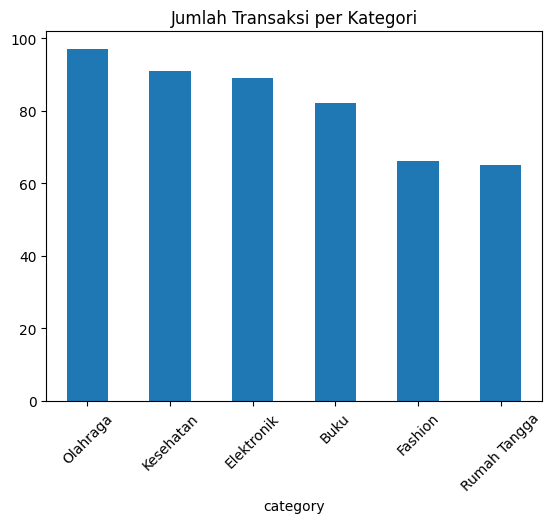

In [22]:
per_kategori = df["category"].value_counts()
print(per_kategori)
print("Total:", per_kategori.sum())
per_kategori.astype(int).plot(kind="bar", title="Jumlah Transaksi per Kategori", rot=45);

ada **6 kategori** dan totalnya **490**, sama dengan jumlah baris bersih. **Olahraga** terbanyak (97 transaksi) dan **Rumah Tangga** paling sedikit (65). Sebaran cukup merata karena kategori dipilih acak.

## R. Tugas Praktikum — Checklist Pengumpulan

In [23]:
import os

daftar = {
    "transaksi_mentah.csv ada": os.path.exists("transaksi_mentah.csv"),
    "transaksi_bersih.csv ada": os.path.exists("transaksi_bersih.csv"),
    "transaksi_bersih.csv = 490 baris": len(pd.read_csv("transaksi_bersih.csv")) == 490,
}
for k, v in daftar.items():
    print("[OK]" if v else "[X] ", k)

[OK] transaksi_mentah.csv ada
[OK] transaksi_bersih.csv ada
[OK] transaksi_bersih.csv = 490 baris


semua harus `[OK]`. Simpan notebook (dengan output tersimpan) dan `transaksi_bersih.csv` ke folder `Praktikum02` pada git repository, lalu kumpulkan laporan PDF lewat iLearn (deadline **17 September 2026, 19.00 WIB**).

## S. Pertanyaan Evaluasi

**1. Perbedaan `dropna()` dan `fillna()`; kapan dipakai?**
`dropna()` membuang baris yang kosong; dipakai bila kolom itu **wajib** dan tanpanya baris tidak bermakna (`customer_name`, `payment_method`). `fillna()` mengisi nilai pengganti; dipakai bila baris masih berguna dan ada nilai pengganti yang jujur (`shipping_city` → "Tidak Diketahui").

**2. Mengapa `drop_duplicates()` sebaiknya di awal pipeline?**
Agar duplikat tidak ikut diproses (menghemat kerja) dan tidak mengacaukan hitungan. Pada praktikum ini terbukti: 15 duplicate terdeteksi pada data mentah, tetapi tinggal 5 setelah `dropna` lebih dulu membuang sebagian salinannya.

**3. Risiko `pd.to_datetime(..., format="mixed", dayfirst=True)`?**
`dayfirst=True` ikut membalik tanggal ISO (`YYYY-MM-DD`) yang sebenarnya tidak ambigu, sehingga misalnya `2026-07-11` bisa terbaca `2026-11-07`. Tanggalnya salah tanpa error, sehingga sulit dideteksi. Solusinya: coba format eksplisit satu per satu (`parse_tanggal()`).

**4. Mengapa `rating` tidak di-impute, tetapi `shipping_city` diisi "Tidak Diketahui"?**
`rating` adalah opini opsional; angka tebakan akan merusak rata-rata (terbukti: rata-rata jatuh dari sekitar 3,12 ke 2,12 bila diisi 0). `shipping_city` adalah kategori; label "Tidak Diketahui" jujur, tidak mengubah statistik lain, dan barisnya tetap terpakai.

**5. Keterkaitan dengan Veracity (5V)?**
Veracity = kepercayaan terhadap data. Praktikum ini menaikkan Veracity dengan membuang duplikat, menangani data kosong, dan menyeragamkan tipe/format. Volume besar tidak berguna bila kualitasnya buruk (*garbage in, garbage out*).

## T. Kesimpulan
Praktikum ini mensimulasikan *data acquisition* dari sumber transaksional, lalu melakukan *preprocessing* penuh: penanganan **missing value**, penghapusan **duplicate**, koreksi **tipe data**, dan standardisasi **format** teks serta tanggal. Dari **515** baris data mentah diperoleh **490** baris data bersih (`transaksi_bersih.csv`) yang siap dipakai pada Praktikum 3 (penyimpanan Parquet).

**Daftar Pustaka:** McKinney (2022) *Python for Data Analysis* 3rd ed.; pandas documentation; Faker documentation; Marz & Warren (2015) *Big Data*; Materi kuliah Pertemuan 2.